<a href="https://colab.research.google.com/github/aluminium5/Hack-O-Week-Sem-V-2026-27/blob/main/Week_5_6_Linear_Algebra_Calculus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hack-o-week — Weeks 5 & 6: Linear Algebra & Calculus

An intuition-first mathematics notebook applied directly to the real-estate dataset.

## Dataset
This notebook uses **Real estate valuation data set.csv**. The target variable is `Y house price of unit area`.

The dataset contains **414 rows and 8 columns**.

## Learning objectives
- Represent real-estate observations as vectors.
- Perform matrix operations and dot products.
- Understand eigenvalues/eigenvectors through covariance/PCA intuition.
- Compute numerical derivatives.
- Understand gradients and the chain rule through a simple regression-loss example.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("Real estate valuation data set.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [2]:
features = df[
    [
        "X2 house age",
        "X3 distance to the nearest MRT station",
        "X4 number of convenience stores",
        "X5 latitude",
        "X6 longitude"
    ]
].to_numpy(dtype=float)

target = df["Y house price of unit area"].to_numpy(dtype=float)

print("Feature matrix shape:", features.shape)
print("Target vector shape:", target.shape)

Feature matrix shape: (414, 5)
Target vector shape: (414,)


## 1. Vectors and dot product

In [3]:
v = features[0]
w = features[1]

dot_product = np.dot(v, w)
print("v =", v)
print("w =", w)
print("v · w =", dot_product)

v = [ 32.       84.87882  10.       24.98298 121.54024]
w = [ 19.5     306.5947    9.       24.98034 121.53951]
v · w = 42133.420903749604


### Practical interpretation
A dot product combines corresponding feature values. In machine learning, a weighted feature vector is combined with model parameters using a dot product.

In [4]:
# A simple weighted score after scaling features
mu = features.mean(axis=0)
sigma = features.std(axis=0)
Z = (features - mu) / sigma

weights = np.array([0.4, -0.5, 0.3, 0.1, 0.1])
scores = Z @ weights

pd.DataFrame({"score": scores[:10]})

,score
0,1.658140
1,1.002749
2,0.361761
3,0.361761
4,0.063187
5,-1.101514
6,1.172113
7,0.751207
8,-2.044302
9,-0.516930


## 2. Matrices and matrix multiplication

In [5]:
A = Z[:5]
B = weights.reshape(-1, 1)

result = A @ B
print("A shape:", A.shape)
print("B shape:", B.shape)
print("A @ B shape:", result.shape)
print(result)

A shape: (5, 5)
B shape: (5, 1)
A @ B shape: (5, 1)
[[1.65814029]
 [1.00274947]
 [0.36176109]
 [0.36176109]
 [0.06318717]]


## 3. Covariance matrix and eigenvalues

In [6]:
cov_matrix = np.cov(Z, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues:", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)
print("Variance explained:", eigenvalues / eigenvalues.sum())

Eigenvalues: [2.68011868 1.0232136  0.60604856 0.55099169 0.151734  ]
Eigenvectors (columns):
 [[-0.00479857 -0.97502535 -0.21360464  0.05935791  0.01233849]
 [ 0.57031005 -0.06549857  0.21345891 -0.09860281 -0.7843272 ]
 [-0.46149363 -0.10204392  0.23514166 -0.83445122 -0.15814626]
 [-0.44971892 -0.12453992  0.70628114  0.49842074 -0.18704657]
 [-0.50941137  0.13824744 -0.59555327  0.20499283 -0.56980869]]
Variance explained: [0.53472899 0.20414841 0.12091694 0.10993216 0.0302735 ]


### Intuition
Eigenvectors identify directions in feature space that remain directionally stable under the covariance transformation. Their eigenvalues indicate how much variance is associated with those directions. This is the key intuition behind PCA.

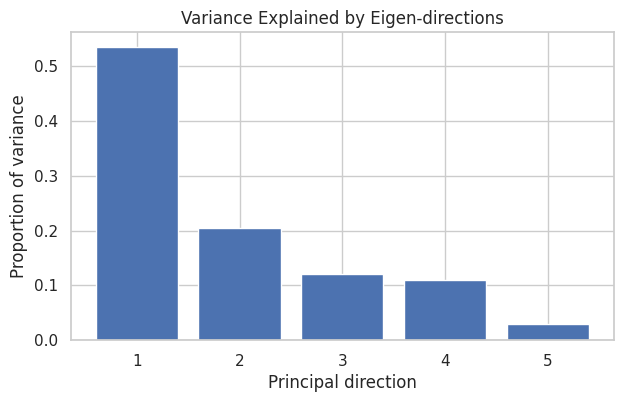

In [7]:
explained = eigenvalues / eigenvalues.sum()
plt.figure(figsize=(7,4))
plt.bar(range(1, len(explained)+1), explained)
plt.xlabel("Principal direction")
plt.ylabel("Proportion of variance")
plt.title("Variance Explained by Eigen-directions")
plt.show()

## 4. Derivative — numerical intuition

In [8]:
def mse_loss(w, x, y):
    prediction = w * x
    return np.mean((prediction - y) ** 2)

x = Z[:, 0]  # standardized house age
y = target

w0 = 0.0
eps = 1e-5

numerical_derivative = (
    mse_loss(w0 + eps, x, y) - mse_loss(w0 - eps, x, y)
) / (2 * eps)

print("Numerical derivative at w =", w0, ":", numerical_derivative)

Numerical derivative at w = 0.0 : 5.723231197407585


## 5. Gradient descent intuition

In [9]:
w = 0.0
learning_rate = 0.05
history = []

for epoch in range(100):
    prediction = w * x
    error = prediction - y

    # derivative of mean squared error with respect to w
    gradient = 2 * np.mean(error * x)

    w = w - learning_rate * gradient
    history.append(mse_loss(w, x, y))

print("Learned w:", w)
print("Final loss:", history[-1])

Learned w: -2.86153958512294
Final loss: 1618.9955523353012


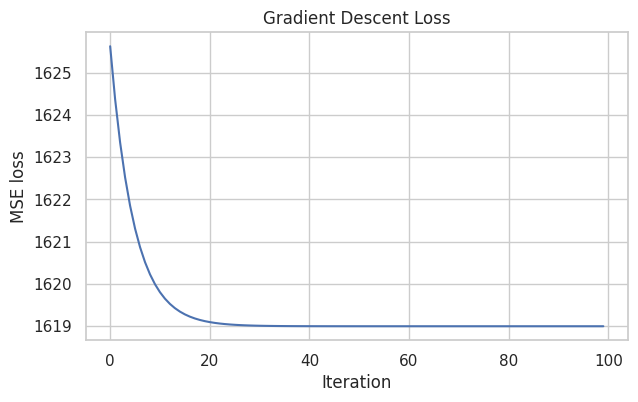

In [10]:
plt.figure(figsize=(7,4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("MSE loss")
plt.title("Gradient Descent Loss")
plt.show()

## 6. Chain rule — backpropagation intuition

In [11]:
# A tiny computational chain:
# z = w*x
# a = z^2
# L = (a-y)^2
#
# Chain rule:
# dL/dw = dL/da * da/dz * dz/dw

x0 = 2.0
y0 = 3.0
w0 = 1.5

z0 = w0 * x0
a0 = z0**2
L0 = (a0 - y0)**2

dL_da = 2 * (a0 - y0)
da_dz = 2 * z0
dz_dw = x0

dL_dw = dL_da * da_dz * dz_dw

print("z =", z0, "a =", a0, "loss =", L0)
print("dL/dw =", dL_dw)

z = 3.0 a = 9.0 loss = 36.0
dL/dw = 144.0


## Week 5–6 mini-task
1. Calculate a dot product using any two observations.
2. Find eigenvalues of the standardized feature covariance matrix and explain which direction carries the most variance.
3. Plot gradient-descent loss for different learning rates.
4. Explain in your own words why the chain rule is important for neural-network backpropagation.

## Conclusion
This notebook connects the mathematical foundations—vectors, matrices, eigenvalues, derivatives and gradients—to operations used by machine-learning algorithms.